# Analyse

## Importations

In [1]:
%load_ext autoreload
%autoreload 2
from plots_e import *
from dataclasses import replace

## Entrainement et affichage DDPG sans couche de normalisation

In [2]:
ddpg_config_sans_couche_de_normalisation = DDPGConfig() #On commence par définir une configuration DDPG par défaut (c'est à dire sans couche de normalisation)



ddpg_sans_couche_de_normalisation = run_ddpg(ddpg_config_sans_couche_de_normalisation)  #On exécute ensuite l'algorithme de DDPG sur notre configuration.

ddpg_sans_couche_de_normalisation.visualize_best() #On visualise le meilleur scenario

  0%|          | 0/30000 [00:00<?, ?it/s]

## Entrainement et affichage TD3 sans couche de normalisation

In [3]:
td3_config_sans_couche_de_normalisation = TD3Config()

td3_sans_couche_de_normalisation = run_td3(td3_config_sans_couche_de_normalisation)
td3_sans_couche_de_normalisation.visualize_best()


  0%|          | 0/30000 [00:00<?, ?it/s]

## Comparaison DDPG vs TD3

Nombre de valeurs de gains moyens de ddpg :  146
Nombre de valeurs de biais de surrestimation de ddpg :  146 

------------------------------------------------------------
Test de Correlation entre reward et overbias pour la variable ddpg Pearson
Coefficient de corrélation : -0.66
P-valeur : 7.383045327028178e-20
------------------------------------------------------------
Test de Correlation entre reward et overbias pour la variable ddpg Spearman
Coefficient de corrélation : -0.52
P-valeur : 2.2962788193163977e-11
------------------------------------------------------------

Nombre de valeurs de gains moyens de td3 :  146
Nombre de valeurs de biais de surrestimation de td3 :  146 

------------------------------------------------------------
Test de Correlation entre reward et overbias pour la variable td3 Pearson
Coefficient de corrélation : -0.48
P-valeur : 6.951973395293251e-10
------------------------------------------------------------
Test de Correlation entre reward et overbias

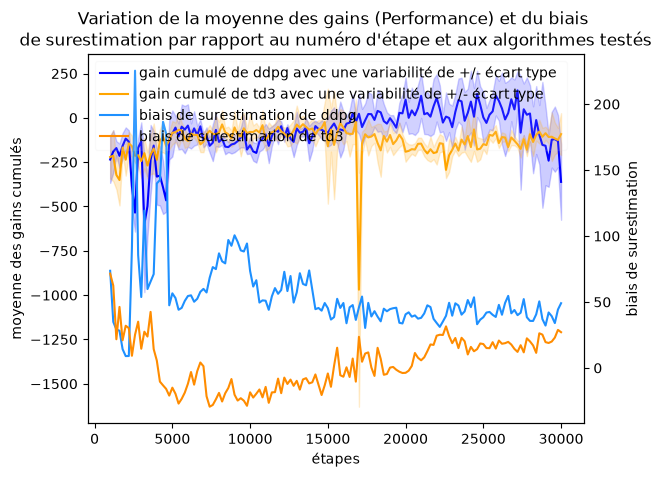

DDPG vs TD3 (final evaluation): t=-3.49, p-value=0.004


In [4]:
plot_evaluations_performance_versus_overbias(ddpg=ddpg_sans_couche_de_normalisation, td3=td3_sans_couche_de_normalisation)



# The Welch t-test tells us whether the difference between the final
# evaluations is statistically significant (p-value < 0.05)
welch = stats.ttest_ind(
    ddpg_sans_couche_de_normalisation.history[-1].rewards.numpy(), td3_sans_couche_de_normalisation.history[-1].rewards.numpy(), equal_var=False
)

print(
    f"DDPG vs TD3 (final evaluation): t={welch.statistic:.2f}, p-value={welch.pvalue:.3f}"
)




In [5]:
setup_tensorboard()

In [ ]:
cfg = td3_config
print(cfg)

TD3Config(env_name='LunarLanderContinuous-v3', seed=1, max_steps=30000, n_envs=1, steps_per_update=1, learning_starts=1000, buffer_size=200000, batch_size=64, gamma=0.98, tau=0.05, action_noise=0.1, actor_hidden=(64, 64), critic_hidden=(64, 64), use_layer_norm=True, lr_actor=0.001, lr_critic=0.001, eval_interval=2000, n_eval_envs=10, policy_delay=2, target_noise=0.2, target_noise_clip=0.5)
